In [1]:
%matplotlib inline

from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import PowerNorm
from scipy.ndimage import gaussian_filter1d
from scipy.stats import circmean, pearsonr, permutation_test, spearmanr

from Utils import rfmap
from Utils.json_tools import read_formatted_json
from Utils.plotting import apply_light_plot_style
from Utils.rf_trials import load_regular_rf_trials
from plotting import plot_1d_rfmap
apply_light_plot_style()



In [2]:
base_dir = Path("/mnt/senzailab/Kai/#Recording/m18")
date = 260812
hd_session_id = 1
rf_session_id = 3
probes = ("A", )

hd_bin_count = 30
hd_smoothing_deg = 3.0
rf_smoothing_bins = 1.5
rf_response_window_s = (0.0, 0.2)
density_bin_count = 12
rf_detection_permutations = 10_000
statistics_permutations = 10_000
rf_detection_seed = 0
statistics_seed = 1

session_dir = base_dir / str(date)
hd_session = session_dir / f"{date}_{hd_session_id}"
rf_session = session_dir / f"{date}_{rf_session_id}"

In [3]:
rf_maps_by_probe = {}
rf_plot_order_by_probe = {}

for probe in probes:
    rf_json_path = (
        rf_session
        / "data/rfmapping/good/0_200_1ms"
        / f"Probe{probe}"
        / f"regular_unitsSpikeCounts_{date}_{rf_session_id}.json"
    )
    probe_maps = rfmap.load_rf_maps(rf_json_path)
    rf_maps_by_probe[probe] = probe_maps
    rf_plot_order_by_probe[probe] = np.argsort(
        np.mod(-probe_maps[0].x_positions, 360.0)
    )

In [4]:
hd_paths_by_probe = {}
for probe in probes:
    tuning_dir = hd_session / f"data/tuning_curves/Probe{probe}"
    preferred_path = tuning_dir / "tuning_curves.tc"
    legacy_path = tuning_dir / "tuning_curves.json"
    hd_paths_by_probe[probe] = (
        preferred_path if preferred_path.is_file() else legacy_path
    )

hd_data_by_probe = {
    probe: read_formatted_json(path)
    for probe, path in hd_paths_by_probe.items()
}
hd_unit_ids_by_probe = {
    probe: np.asarray(data["unit_id"], dtype=int)
    for probe, data in hd_data_by_probe.items()
}
hd_spike_counts_by_probe = {
    probe: np.asarray(data["spike_counts"], dtype=float)
    for probe, data in hd_data_by_probe.items()
}

In [5]:
selected_unit_keys = []
rf_center_angle_by_key = {}

for probe in probes:
    hd_classes = np.asarray(hd_data_by_probe[probe]["unit_data"]["hd_class"])
    eligible_unit_ids = hd_unit_ids_by_probe[probe][hd_classes == 2]

    raw_maps = rf_maps_by_probe[probe]
    available_unit_ids = set(raw_maps.unit_ids)
    candidate_unit_ids = [
        int(unit_id)
        for unit_id in eligible_unit_ids
        if int(unit_id) in available_unit_ids
    ]
    candidate_maps = rfmap.RFMapList(
        [raw_maps.by_unit_id(unit_id) for unit_id in candidate_unit_ids],
        raw_maps.source_path,
    )
    summed_maps = candidate_maps.sum(
        *rf_response_window_s,
        show_progress=False,
    )
    center_masks = summed_maps.rf_2d(
        load_regular_rf_trials(rf_session, probe, summed_maps),
        return_center=True,
        cluster_forming_z=1.5,
        alpha=0.05,
        n_permutations=rf_detection_permutations,
        random_seed=rf_detection_seed,
        wrap_x=True,
        show_progress=False,
    )

    for unit_map, center_mask in zip(summed_maps, center_masks):
        center_indices = np.argwhere(center_mask)
        if center_indices.size == 0:
            continue
        x_index = center_indices[0, 1]
        unit_key = (probe, unit_map.unit_id)
        selected_unit_keys.append(unit_key)
        rf_center_angle_by_key[unit_key] = float(
            np.mod(-unit_map.x_positions[x_index], 360.0)
        )

In [6]:
hd_angle_bin_edges = np.linspace(0.0, 360.0, hd_bin_count + 1)
hd_rate_by_key = {}

for probe in probes:
    probe_keys = [key for key in selected_unit_keys if key[0] == probe]
    row_by_unit_id = {
        int(unit_id): row
        for row, unit_id in enumerate(hd_unit_ids_by_probe[probe])
    }
    rows = [row_by_unit_id[unit_id] for _, unit_id in probe_keys]
    spike_counts = hd_spike_counts_by_probe[probe][rows]
    occupancy = np.asarray(
        hd_data_by_probe[probe]["occupancy_time_s"],
        dtype=float,
    )

    source_bin_count = spike_counts.shape[1]
    bins_per_group = source_bin_count // hd_bin_count
    smoothing_sigma = hd_smoothing_deg / (360.0 / source_bin_count)
    smoothed_counts = gaussian_filter1d(
        spike_counts,
        sigma=smoothing_sigma,
        axis=1,
        mode="wrap",
    ).reshape(len(probe_keys), hd_bin_count, bins_per_group).sum(axis=2)
    smoothed_occupancy = gaussian_filter1d(
        occupancy,
        sigma=smoothing_sigma,
        mode="wrap",
    ).reshape(hd_bin_count, bins_per_group).sum(axis=1)
    probe_rates = np.divide(
        smoothed_counts,
        smoothed_occupancy[None, :],
        out=np.full(smoothed_counts.shape, np.nan),
        where=smoothed_occupancy[None, :] > 0,
    )
    hd_rate_by_key.update(zip(probe_keys, probe_rates))

hd_rates = np.stack([hd_rate_by_key[key] for key in selected_unit_keys])
hd_peak_bin_indices = np.nanargmax(hd_rates, axis=1)
hd_sort_indices = np.argsort(hd_peak_bin_indices)

# RF profiles retain the original full recorded RF timeline.
rf_profiles = np.stack([
    rf_maps_by_probe[probe]
    .by_unit_id(unit_id)
    .spike_counts.sum(axis=(0, 2))[rf_plot_order_by_probe[probe]]
    for probe, unit_id in selected_unit_keys
])
rf_profiles = gaussian_filter1d(
    rf_profiles,
    sigma=rf_smoothing_bins,
    axis=1,
    mode="wrap",
)

In [7]:
def circular_distance_matrix_deg(angles_deg):
    delta = angles_deg[:, None] - angles_deg[None, :]
    return np.abs((delta + 180.0) % 360.0 - 180.0)


def pairing_permutation_p(values, statistic):
    result = permutation_test(
        (values,),
        statistic,
        permutation_type="pairings",
        vectorized=False,
        n_resamples=statistics_permutations,
        alternative="greater",
        rng=np.random.default_rng(statistics_seed),
    )
    return float(result.pvalue)


def circular_correlation(alpha, beta):
    alpha_centered = np.sin(alpha - circmean(alpha))
    beta_centered = np.sin(beta - circmean(beta))
    return float(pearsonr(alpha_centered, beta_centered).statistic)


def circular_correlation_test(alpha, beta):
    rho = circular_correlation(alpha, beta)
    p_value = pairing_permutation_p(
        beta,
        lambda shuffled: abs(circular_correlation(alpha, shuffled)),
    )
    return rho, p_value


def circular_alignment_test(reference, matched):
    residual_vector = np.mean(np.exp(1j * (matched - reference)))
    p_value = pairing_permutation_p(
        matched,
        lambda shuffled: abs(np.mean(np.exp(1j * (shuffled - reference)))),
    )
    return float(np.angle(residual_vector)), float(abs(residual_vector)), p_value


def spearman_mantel_test(hd_angles_deg, rf_angles_deg):
    upper_triangle = np.triu_indices(hd_angles_deg.size, k=1)
    hd_distances = circular_distance_matrix_deg(hd_angles_deg)[upper_triangle]

    def statistic(shuffled_rf_angles):
        rf_distances = circular_distance_matrix_deg(
            shuffled_rf_angles
        )[upper_triangle]
        return float(spearmanr(hd_distances, rf_distances).statistic)

    rho = statistic(rf_angles_deg)
    p_value = pairing_permutation_p(
        rf_angles_deg,
        lambda shuffled: abs(statistic(shuffled)),
    )
    return rho, p_value

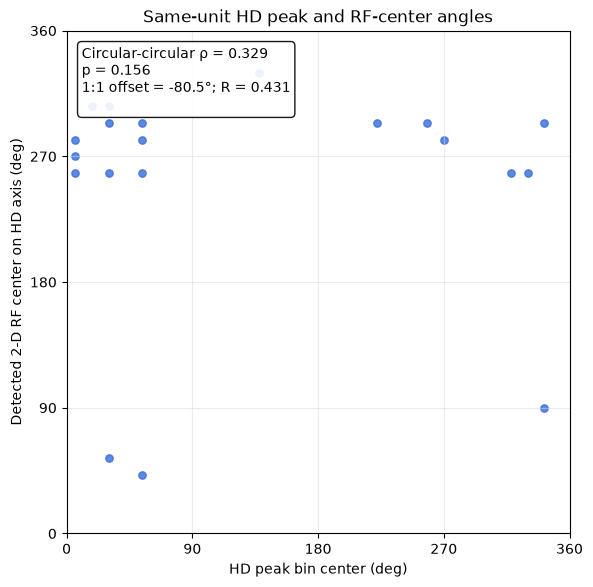

{'circular_correlation_rho': 0.32909554334659563,
 'permutation_p': 0.15598440155984403,
 'one_to_one_offset_deg': -80.48140970769842,
 'alignment_resultant': 0.43147838631012525,
 'alignment_permutation_p': 0.42745725427457254,
 'unit_count': 20,
 'HD_mean_resultant_length': 0.5877423020624769,
 'RF_mean_resultant_length': 0.6977780496761326}

In [8]:
hd_angle_bin_centers = (hd_angle_bin_edges[:-1] + hd_angle_bin_edges[1:]) / 2
hd_peak_angle_by_key = dict(zip(
    selected_unit_keys,
    hd_angle_bin_centers[hd_peak_bin_indices],
))
hd_peak_angles_deg = np.asarray([
    hd_peak_angle_by_key[key] for key in selected_unit_keys
])
rf_center_angles_deg = np.asarray([
    rf_center_angle_by_key[key] for key in selected_unit_keys
])
hd_peak_angles_rad = np.deg2rad(hd_peak_angles_deg)
rf_center_angles_rad = np.deg2rad(rf_center_angles_deg)

rho_circ, p_circ = circular_correlation_test(
    hd_peak_angles_rad,
    rf_center_angles_rad,
)
alignment_offset_rad, alignment_resultant, p_alignment = circular_alignment_test(
    hd_peak_angles_rad,
    rf_center_angles_rad,
)
alignment_offset_deg = float(np.rad2deg(alignment_offset_rad))
hd_mean_resultant = float(abs(np.mean(np.exp(1j * hd_peak_angles_rad))))
rf_mean_resultant = float(abs(np.mean(np.exp(1j * rf_center_angles_rad))))

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(hd_peak_angles_deg, rf_center_angles_deg, s=28, alpha=0.8)
ax.set(
    xlabel="HD peak bin center (deg)",
    ylabel="Detected 2-D RF center on HD axis (deg)",
    title="Same-unit HD peak and RF-center angles",
    xlim=(0, 360),
    ylim=(0, 360),
    xticks=np.arange(0, 361, 90),
    yticks=np.arange(0, 361, 90),
)
ax.text(
    0.03,
    0.97,
    (
        f"Circular-circular ρ = {rho_circ:.3f}\n"
        f"p = {p_circ:.4g}\n"
        f"1:1 offset = {alignment_offset_deg:+.1f}°; "
        f"R = {alignment_resultant:.3f}\n"
    ),
    transform=ax.transAxes,
    ha="left",
    va="top",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.9},
)
ax.set_aspect("equal", adjustable="box")
ax.grid(color="0.85", linewidth=0.8)
fig.tight_layout()
plt.show()

same_unit_statistics = {
    "circular_correlation_rho": rho_circ,
    "permutation_p": p_circ,
    "one_to_one_offset_deg": alignment_offset_deg,
    "alignment_resultant": alignment_resultant,
    "alignment_permutation_p": p_alignment,
    "unit_count": len(selected_unit_keys),
    "HD_mean_resultant_length": hd_mean_resultant,
    "RF_mean_resultant_length": rf_mean_resultant,
}
same_unit_statistics

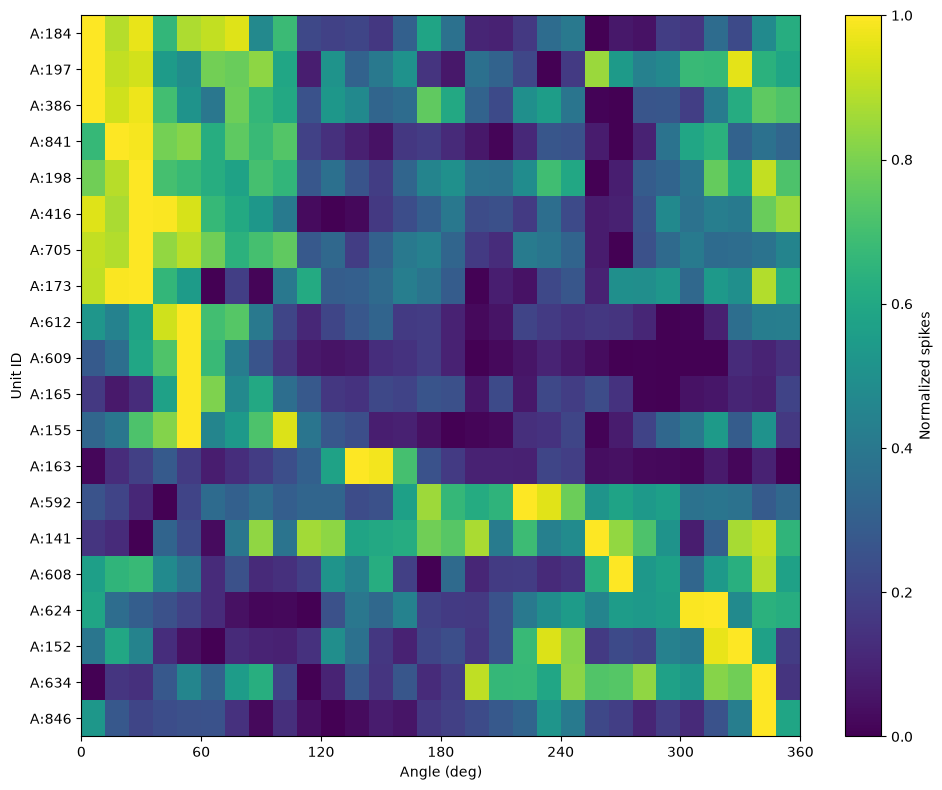

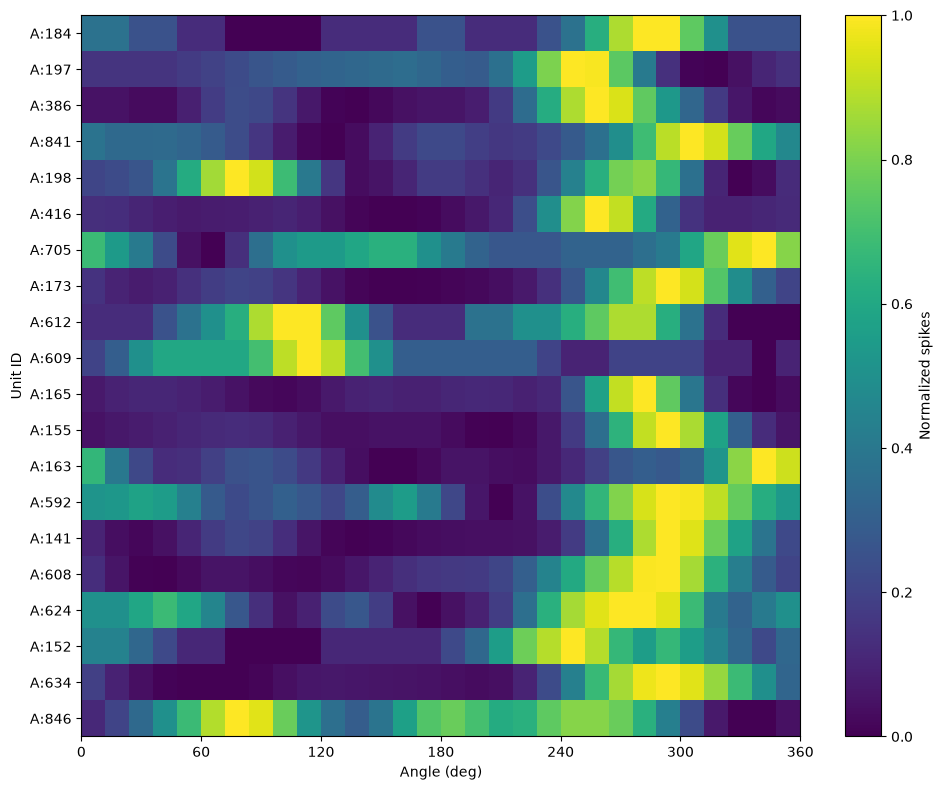

In [9]:
hd_sorted_labels = [
    f"{selected_unit_keys[index][0]}:{selected_unit_keys[index][1]}"
    for index in hd_sort_indices
]

plot_1d_rfmap(
    hd_rates[hd_sort_indices],
    label_list=hd_sorted_labels,
    isHeatmap=True,
    xinDeg=True,
    isNormalize=True,
)
plot_1d_rfmap(
    rf_profiles[hd_sort_indices],
    label_list=hd_sorted_labels,
    isHeatmap=True,
    xinDeg=True,
    isNormalize=True,
)

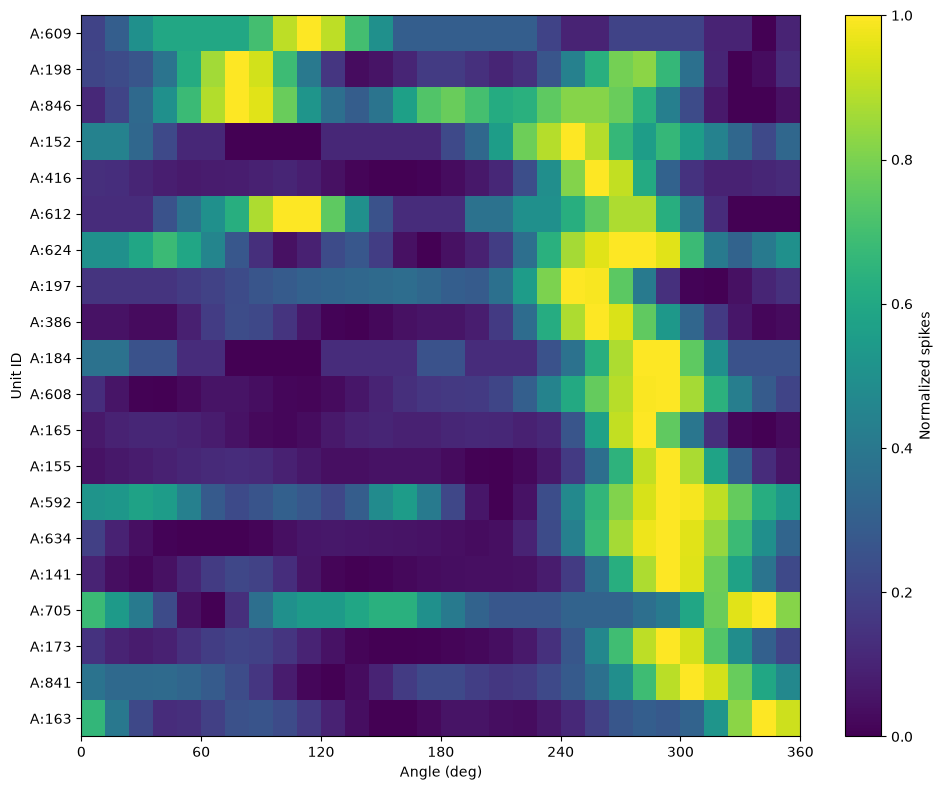

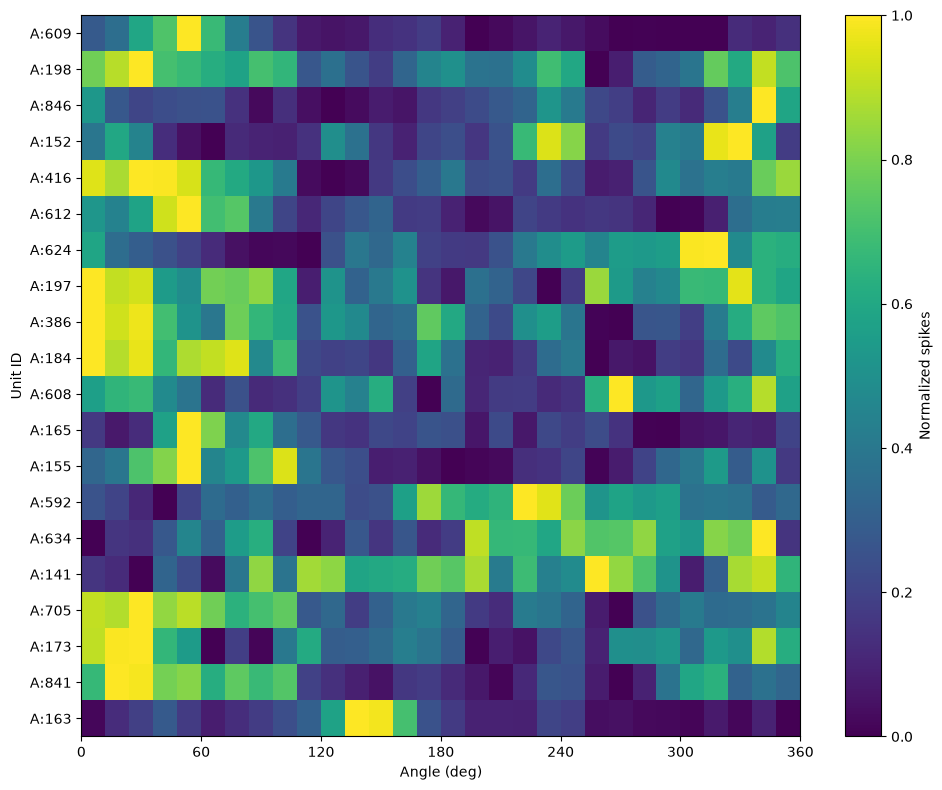

In [10]:
rf_center_sort_indices = np.argsort(rf_center_angles_deg)
rf_center_sorted_labels = [
    f"{selected_unit_keys[index][0]}:{selected_unit_keys[index][1]}"
    for index in rf_center_sort_indices
]

plot_1d_rfmap(
    rf_profiles[rf_center_sort_indices],
    label_list=rf_center_sorted_labels,
    isHeatmap=True,
    xinDeg=True,
    isNormalize=True,
)
plot_1d_rfmap(
    hd_rates[rf_center_sort_indices],
    label_list=rf_center_sorted_labels,
    isHeatmap=True,
    xinDeg=True,
    isNormalize=True,
)

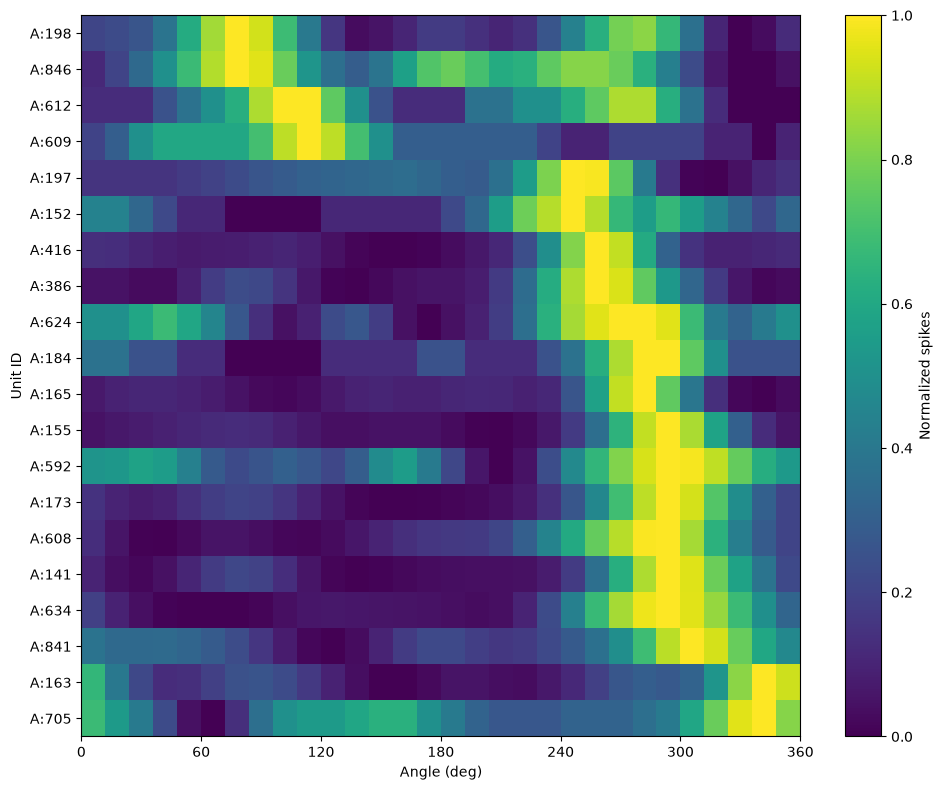

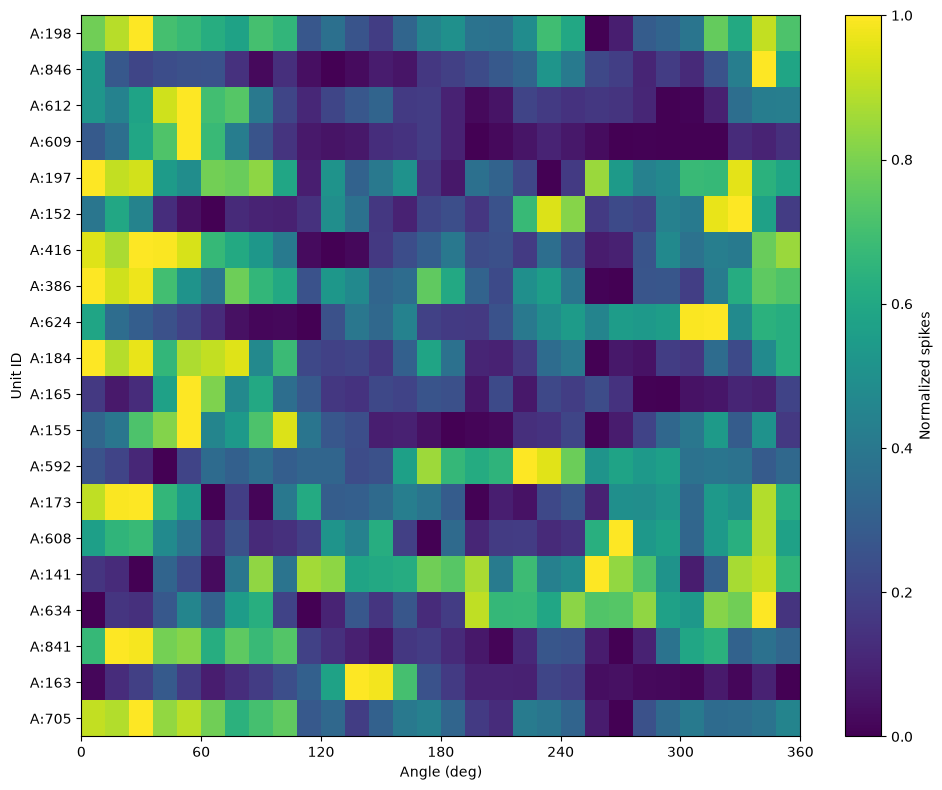

In [11]:
rf_peak_bin_indices = np.nanargmax(rf_profiles, axis=1)
rf_peak_sort_indices = np.argsort(rf_peak_bin_indices)
rf_peak_sorted_labels = [
    f"{selected_unit_keys[index][0]}:{selected_unit_keys[index][1]}"
    for index in rf_peak_sort_indices
]

plot_1d_rfmap(
    rf_profiles[rf_peak_sort_indices],
    label_list=rf_peak_sorted_labels,
    isHeatmap=True,
    xinDeg=True,
    isNormalize=True,
)
plot_1d_rfmap(
    hd_rates[rf_peak_sort_indices],
    label_list=rf_peak_sorted_labels,
    isHeatmap=True,
    xinDeg=True,
    isNormalize=True,
)

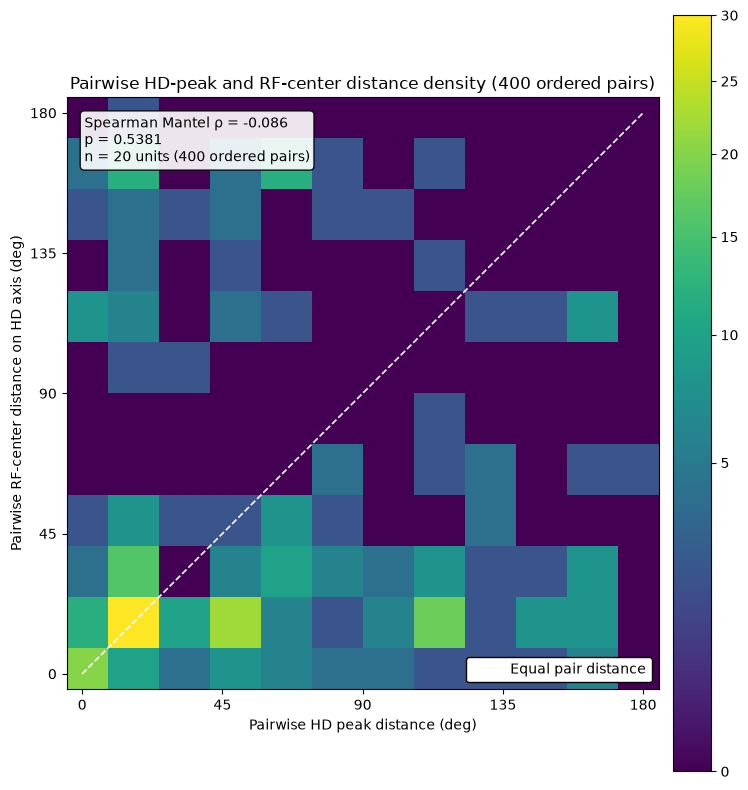

{'spearman_mantel_rho': -0.0864079023057089,
 'permutation_p': 0.5381461853814619,
 'unit_count': 20,
 'ordered_pair_count': 400}

In [12]:
mantel_rho, mantel_p = spearman_mantel_test(
    hd_peak_angles_deg,
    rf_center_angles_deg,
)
hd_pair_distances_deg = circular_distance_matrix_deg(hd_peak_angles_deg).ravel()
rf_pair_distances_deg = circular_distance_matrix_deg(rf_center_angles_deg).ravel()
ordered_pair_count = hd_pair_distances_deg.size

density_bin_width_deg = 180.0 / (density_bin_count - 1)
density_bin_edges = np.linspace(
    -density_bin_width_deg / 2.0,
    180.0 + density_bin_width_deg / 2.0,
    density_bin_count + 1,
)
fig, ax = plt.subplots(figsize=(8, 8))
density_image = ax.hist2d(
    hd_pair_distances_deg,
    rf_pair_distances_deg,
    bins=(density_bin_edges, density_bin_edges),
    cmap="viridis",
    norm=PowerNorm(gamma=0.5, vmin=0),
)[3]
fig.colorbar(density_image, ax=ax, pad=0.02)
ax.plot(
    [0, 180],
    [0, 180],
    linestyle="--",
    linewidth=1.2,
    color="white",
    label="Equal pair distance",
)
ax.legend(loc="lower right")
ax.set(
    xlabel="Pairwise HD peak distance (deg)",
    ylabel="Pairwise RF-center distance on HD axis (deg)",
    title=f"Pairwise HD-peak and RF-center distance density ({ordered_pair_count} ordered pairs)",
    xlim=(-5, 185),
    ylim=(-5, 185),
    xticks=np.arange(0, 181, 45),
    yticks=np.arange(0, 181, 45),
)
ax.text(
    0.03,
    0.97,
    (
        f"Spearman Mantel ρ = {mantel_rho:.3f}\n"
        f"p = {mantel_p:.4g}\n"
        f"n = {len(selected_unit_keys)} units ({ordered_pair_count} ordered pairs)"
    ),
    transform=ax.transAxes,
    ha="left",
    va="top",
    color="black",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.9},
)
ax.set_aspect("equal", adjustable="box")
fig.tight_layout()
plt.show()

pairwise_statistics = {
    "spearman_mantel_rho": mantel_rho,
    "permutation_p": mantel_p,
    "unit_count": len(selected_unit_keys),
    "ordered_pair_count": ordered_pair_count,
}
pairwise_statistics